In [1]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("..") / ".env")

True

In [2]:
log = kairo.read_log("../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    #event_id = "event:uidd",
    start_timestamp = "start:timestamp",
    resource = "org:resource",
    #event_duration = "event:runtime_min")
    )
log.head()

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 32429/32429 [00:03<00:00, 10007.32it/s]


,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
0,Request created,2017-05-29 08:47:46+00:00,2017-05-29 08:49:25+00:00,6,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
1,Evaluating Request (NO registered letter),2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,7,DIRECTOR,complete,Client Recess,1 - Client lost,case_000000
2,Service closure Request with network responsib...,2017-05-29 08:56:04+00:00,2017-05-29 09:02:39+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
3,Service closure Request with BO responsibility,2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,BOF,BACK-OFFICE,complete,Client Recess,1 - Client lost,case_000000
4,Network Adjustment Requested,2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000


In [3]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 32429,
 'events': 212721,
 'activities': 15,
 'resources': 654,
 'start': Timestamp('2017-05-29 08:49:25+0000', tz='UTC'),
 'end': Timestamp('2019-03-06 16:38:59+0000', tz='UTC'),
 'span_minutes': 930709.5666666667,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 13.45629664160194,
 'tpt_days_median': 6.074346064814815,
 'tpt_days_max': 503.5870949074074,
 'length_min': 2,
 'length_mean': 6.559591723457399,
 'length_median': 7.0,
 'length_max': 23,
 'activity_counts': concept:name
 Request created                                        32377
 Service closure Request with BO responsibility         30130
 Pending Request for Reservation Closure                29151
 Request completed with account closure                 29031
 Pending Liquidation Request                            29000
 Service closure Request with network responsibility    25009
 Authorization Requested                                12675
 Evaluating Request (NO registered letter)              11080
 Back-Office Adj

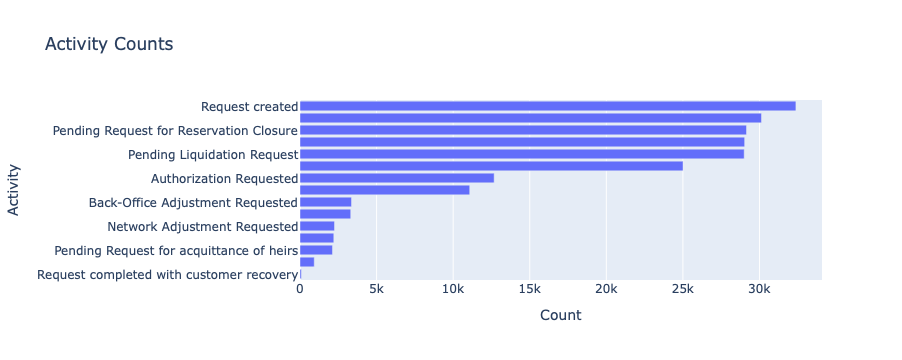

In [4]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [5]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


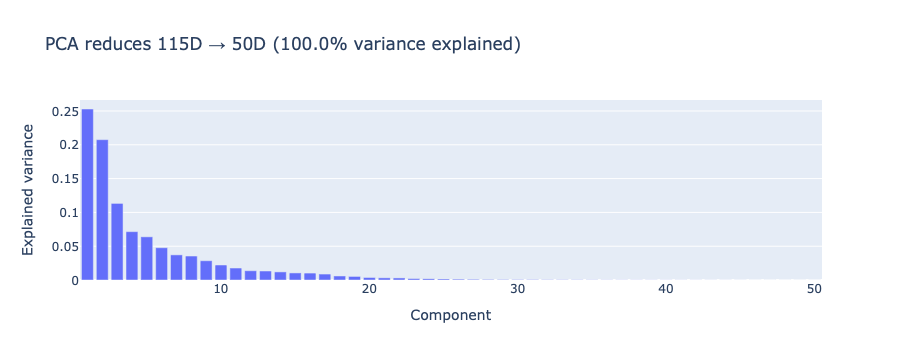

In [7]:
pca = kairo.compute_pca(std_features, num_components=50)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [8]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=13)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800


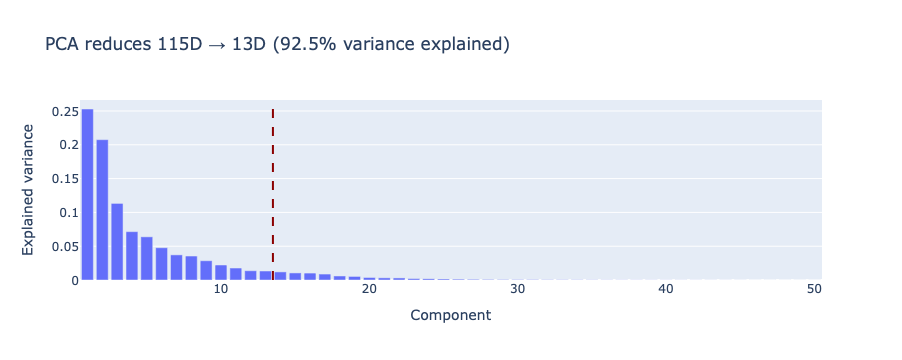

In [9]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=13)
pca_plot_cut.show()

In [10]:
som = kairo.compute_som(compressed_features, size=(10,10))
clusters = kairo.get_som_winners(compressed_features, som)
clusters

,i,j
0,0,0
1,9,4
2,0,7
3,9,9
4,1,8
...,...,...
212716,3,0
212717,0,2
212718,3,0
212719,0,2


In [11]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,i,j
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787,0,0
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555,9,4
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936,0,7
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696,9,9
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,3,0
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0,2
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,3,0
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0,2


In [12]:
state_distances = kairo.get_som_state_distances(som)
state_distances

,"(0, 0)","(0, 1)","(0, 2)","(0, 3)","(0, 4)","(0, 5)","(0, 6)","(0, 7)","(0, 8)","(0, 9)",...,"(9, 0)","(9, 1)","(9, 2)","(9, 3)","(9, 4)","(9, 5)","(9, 6)","(9, 7)","(9, 8)","(9, 9)"
"(0, 0)",0.000000,0.083262,0.166257,1.284951,3.719670,3.675614,2.593160,2.771265,2.745398,3.345867,...,2.775160,2.376947,1.976909,2.154543,2.345580,2.659389,3.992450,3.934114,3.061794,3.127066
"(0, 1)",0.083262,0.000000,0.082994,1.241859,3.681498,3.639059,2.556886,2.751982,2.715687,3.313559,...,2.757484,2.356943,1.955902,2.144443,2.337926,2.624210,3.949278,3.889667,3.032236,3.101940
"(0, 2)",0.166257,0.082994,0.000000,1.203112,3.644943,3.604167,2.522946,2.735150,2.688313,3.283141,...,2.742267,2.339783,1.938299,2.137559,2.333231,2.591332,3.907536,3.846644,3.004780,3.078931
"(0, 3)",1.284951,1.241859,1.203112,0.000000,2.444620,2.418902,1.635115,2.695414,2.482031,2.977879,...,2.328252,1.964030,2.057665,2.266412,2.455614,2.320647,3.454499,3.374922,2.771213,2.902947
"(0, 4)",3.719670,3.681498,3.644943,2.444620,0.000000,0.460065,2.033445,3.985791,3.626665,3.775301,...,3.127015,3.053251,3.808117,3.914519,4.025486,3.444865,3.814319,3.723599,3.762844,3.937207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(9, 5)",2.659389,2.624210,2.591332,2.320647,3.444865,3.392808,2.130923,2.299855,1.861191,2.323386,...,3.247422,2.921460,2.639826,1.825867,1.835585,0.000000,1.922152,1.872966,2.180518,2.268746
"(9, 6)",3.992450,3.949278,3.907536,3.454499,3.814319,3.757117,3.007225,3.419811,2.857078,2.888161,...,4.230018,4.040735,4.092711,3.731992,3.757737,1.922152,0.000000,0.322048,2.984889,3.043547
"(9, 7)",3.934114,3.889667,3.846644,3.374922,3.723599,3.703311,2.938213,3.357840,2.778052,2.803627,...,4.183065,3.988252,4.026880,3.667776,3.695493,1.872966,0.322048,0.000000,2.830872,2.947960
"(9, 8)",3.061794,3.032236,3.004780,2.771213,3.762844,3.804429,2.475053,2.339951,1.755385,2.073567,...,3.359595,3.118959,3.193974,2.734020,2.771989,2.180518,2.984889,2.830872,0.000000,0.751538


In [37]:
state_freqs = kairo.get_som_state_frequencies(features_and_clusters)
state_freqs

state
(0, 0)     4394
(0, 1)      178
(0, 2)     3235
(0, 3)        1
(0, 4)     1480
          ...  
(9, 4)    11074
(9, 6)    10294
(9, 7)      251
(9, 8)      321
(9, 9)    10960
Name: events, Length: 90, dtype: int64

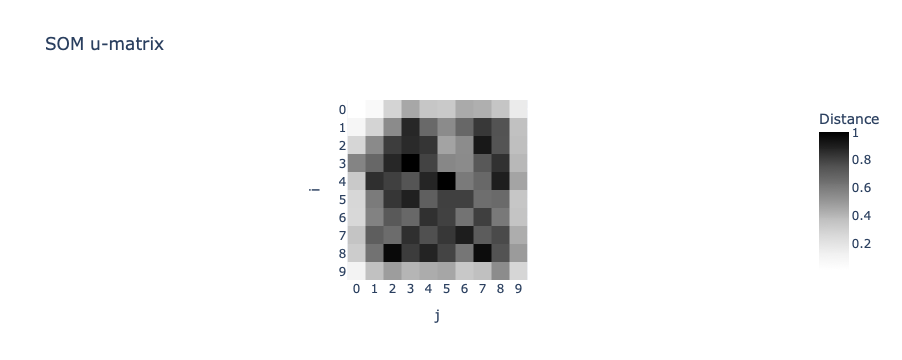

In [13]:
u_matrix_plot = kairo.plot_som_u_matrix(som)
u_matrix_plot.show()

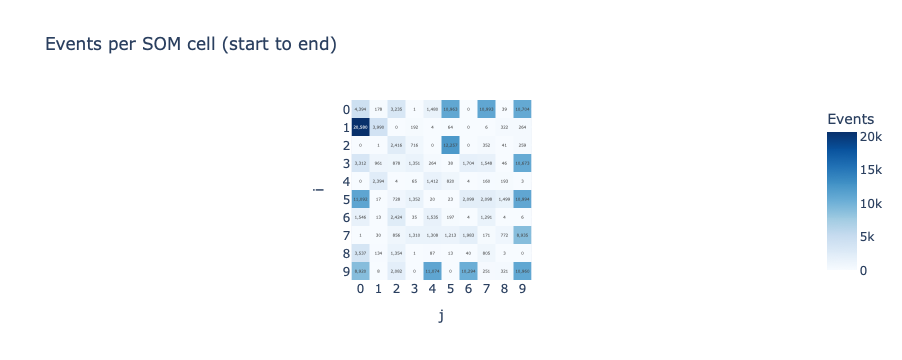

In [14]:
heatmap_plot = kairo.plot_som_heatmap(features_and_clusters, size=(10,10), 
                                 #start_date="2010-04-29", 
                                 #end_date="2018-05-29"
                                 )
heatmap_plot.show()

In [15]:
color_mapping = kairo.compute_som_color_mapping((10,10))
#color_mapping

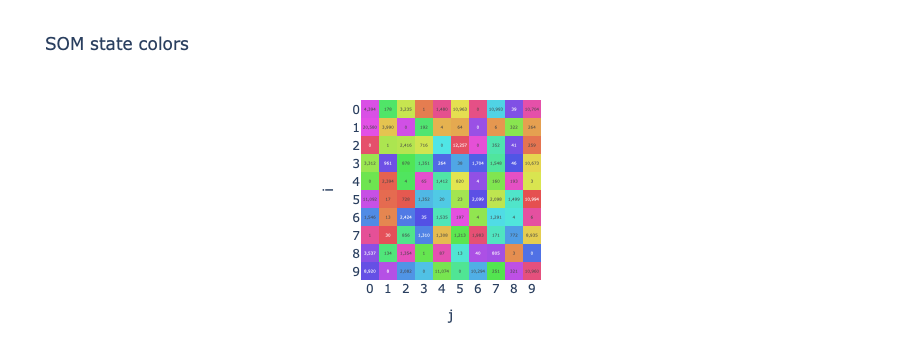

In [16]:
state_colors_plot = kairo.plot_som_colors(features_and_clusters, color_mapping)
state_colors_plot.show()

In [17]:
case_trajectory = kairo.get_som_case_trajectory(features_and_clusters, case_id="case_000001")
case_trajectory

,state,start,end,duration,events
0,"(0, 0)",2017-06-05 13:34:59+00:00,2017-06-05 14:20:48+00:00,0 days 00:45:49,1
1,"(6, 0)",2017-06-05 14:20:48+00:00,2017-06-12 08:28:02+00:00,6 days 18:07:14,1
2,"(8, 0)",2017-06-12 08:28:02+00:00,2017-06-14 10:11:14+00:00,2 days 01:43:12,1
3,"(2, 5)",2017-06-14 10:11:14+00:00,2018-02-09 13:13:06+00:00,240 days 03:01:52,1
4,"(3, 7)",2018-02-09 13:13:06+00:00,2018-02-26 15:05:05+00:00,17 days 01:51:59,1
5,"(3, 6)",2018-02-26 15:05:05+00:00,2018-09-10 10:53:14+00:00,195 days 19:48:09,1
6,"(3, 7)",2018-09-10 10:53:14+00:00,2018-09-11 08:43:15+00:00,0 days 21:50:01,1
7,"(3, 6)",2018-09-11 08:43:15+00:00,2018-09-11 08:43:30+00:00,0 days 00:00:15,1
8,"(5, 8)",2018-09-11 08:43:30+00:00,2018-09-13 03:04:02+00:00,1 days 18:20:32,1
9,"(0, 4)",2018-09-13 03:04:02+00:00,2018-09-13 08:57:36+00:00,0 days 05:53:34,1


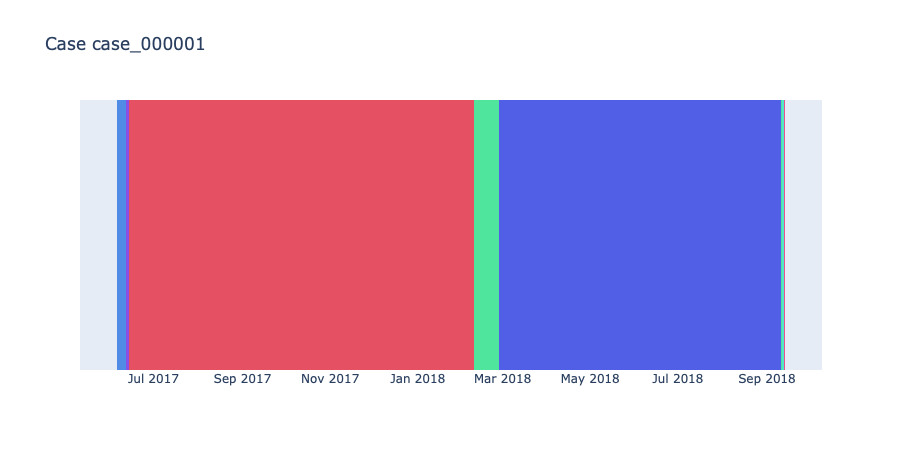

In [19]:
case_trajectory_plot = kairo.plot_som_case_trajectory(case_trajectory, color_mapping, case_id="case_000001")
case_trajectory_plot

In [25]:
case_trajectories = kairo.get_som_trajectories(features_and_clusters, max_cases=20)
case_trajectories

,case,state,start,end,duration,events
0,case_000000,"(0, 0)",2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,0 days 00:03:24,1
1,case_000000,"(9, 4)",2017-05-29 08:52:49+00:00,2017-05-29 09:02:39+00:00,0 days 00:09:50,1
2,case_000000,"(0, 7)",2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,0 days 02:20:54,1
3,case_000000,"(9, 9)",2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,1 days 22:02:35,1
4,case_000000,"(1, 8)",2017-05-31 09:26:08+00:00,2017-06-12 08:45:01+00:00,11 days 23:18:53,1
...,...,...,...,...,...,...
164,case_000033,"(3, 6)",2018-09-06 10:49:26+00:00,2018-09-06 10:50:54+00:00,0 days 00:01:28,1
165,case_000033,"(5, 8)",2018-09-06 10:50:54+00:00,2018-09-08 03:17:15+00:00,1 days 16:26:21,1
166,case_000033,"(0, 4)",2018-09-08 03:17:15+00:00,2018-09-10 14:54:54+00:00,2 days 11:37:39,1
167,case_000033,"(5, 7)",2018-09-10 14:54:54+00:00,2018-09-10 14:54:54+00:00,0 days 00:00:00,1


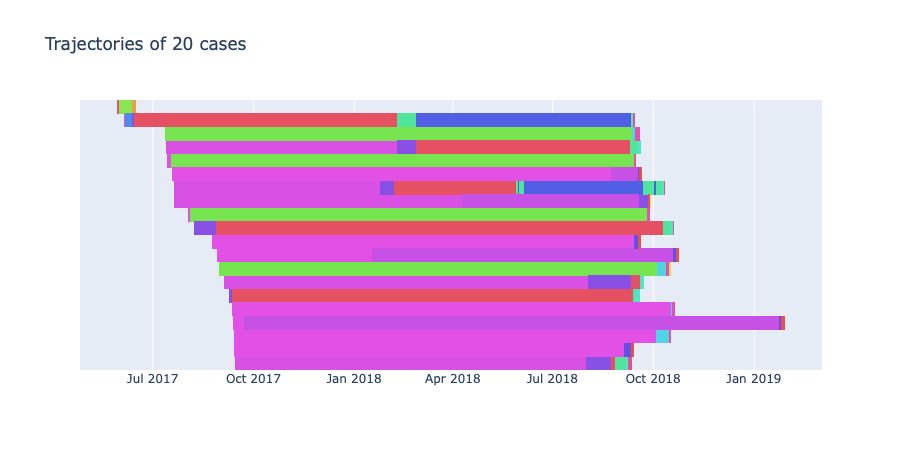

In [26]:
case_trajectories_plot = kairo.plot_som_trajectories(case_trajectories, color_mapping)
case_trajectories_plot

In [27]:
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="30D")
freq_distributions

state,"(0, 0)","(0, 1)","(0, 2)","(0, 3)","(0, 4)","(0, 5)","(0, 7)","(0, 8)","(0, 9)","(1, 0)",...,"(8, 7)","(8, 8)","(9, 0)","(9, 1)","(9, 2)","(9, 4)","(9, 6)","(9, 7)","(9, 8)","(9, 9)"
window,,,,,,,,,,,,,,,,,,,,,
2017-05-24 00:00:00+00:00,0.153846,0.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.076923,0.076923,0.076923
2017-06-23 00:00:00+00:00,0.375000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.375000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000
2017-07-23 00:00:00+00:00,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000
2017-08-22 00:00:00+00:00,0.277778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.055556,0.000000,0.000000,0.000000,0.000000
2017-09-21 00:00:00+00:00,0.193548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.322581,...,0.000000,0.000000,0.000000,0.000000,0.032258,0.096774,0.000000,0.000000,0.000000,0.000000
2017-10-21 00:00:00+00:00,0.142857,0.057143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,0.028571,0.057143,0.000000,0.000000,0.000000,0.000000
2017-11-20 00:00:00+00:00,0.209302,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.116279,...,0.000000,0.000000,0.000000,0.000000,0.023256,0.093023,0.000000,0.000000,0.000000,0.000000
2017-12-20 00:00:00+00:00,0.210526,0.000000,0.000000,0.000000,0.000000,0.017544,0.000000,0.000000,0.000000,0.175439,...,0.000000,0.000000,0.017544,0.000000,0.000000,0.052632,0.000000,0.000000,0.000000,0.000000
2018-01-19 00:00:00+00:00,0.084337,0.000000,0.000000,0.000000,0.000000,0.000000,0.012048,0.000000,0.000000,0.313253,...,0.000000,0.000000,0.024096,0.000000,0.012048,0.084337,0.000000,0.000000,0.000000,0.012048


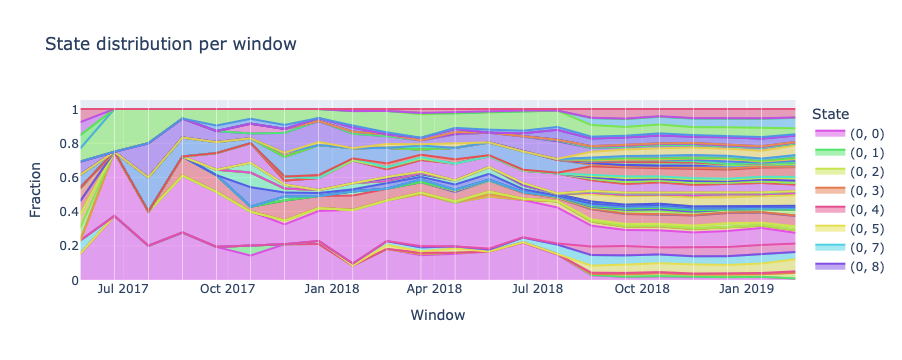

In [28]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [29]:
divergences = kairo.compute_divergences(freq_distributions)
divergences

,window,score
0,2017-05-24 00:00:00+00:00,NaN
1,2017-06-23 00:00:00+00:00,8.032192
2,2017-07-23 00:00:00+00:00,7.349459
3,2017-08-22 00:00:00+00:00,2.118193
4,2017-09-21 00:00:00+00:00,2.784602
5,2017-10-21 00:00:00+00:00,5.031189
6,2017-11-20 00:00:00+00:00,1.978707
7,2017-12-20 00:00:00+00:00,1.320048
8,2018-01-19 00:00:00+00:00,1.568916
9,2018-02-18 00:00:00+00:00,1.813619


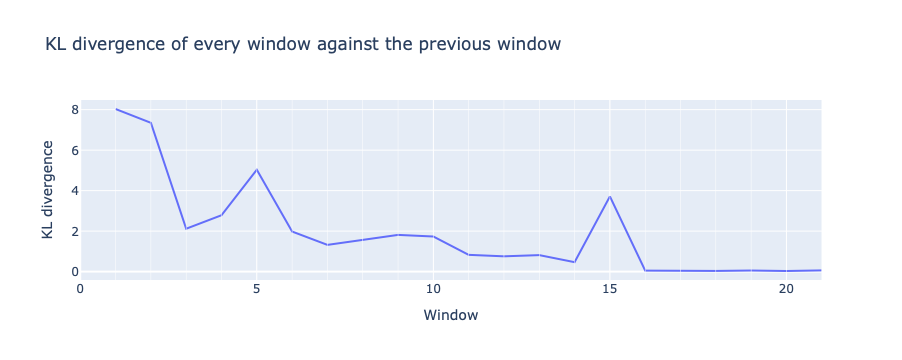

In [31]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [32]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nThroughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.\nEvents per case: min 2, mean 6.6, median 7.0, max 23.\nEvents per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)\nMost active resources: BOF (113,9

In [33]:
abs_features = kairo.abstract_features(features)
abs_features

'Intra-case feature matrix: 212,721 rows, one per event, each describing its case up to and including that event, with 115 feature columns.\nThe events belong to 32,429 cases.\nThey happened from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nFeature groups:\n- act_freqs (share of every activity among the events of the case so far): 15 columns, mean value 0.067, non-zero in 26.4% of the cells, highest column means act_freqs:Request created = 0.378, act_freqs:Service closure Request with network responsibility = 0.162, act_freqs:Service closure Request with BO responsibility = 0.118\n- df_counts (how often every directly-follows pair happened in the case so far): 54 columns, mean value 0.056, non-zero in 5.6% of the cells, highest column means df_counts:Service closure Request with BO responsibility -> Pending Request for Reservation Closure = 0.419, df_counts:Request created -> Service closure Request with network responsibility = 0.387, df_counts:Service closure Request with

In [34]:
abs_pca = kairo.abstract_pca(pca, cut_component=13)
abs_pca

'PCA fitted 50 components on 115 feature columns. The cut keeps the first 13, which explain 92.5% of the variance.\nExplained variance per component: pc_1 25.3%, pc_2 20.8%, pc_3 11.3%, pc_4 7.2%, pc_5 6.4%, pc_6 4.8%, pc_7 3.7%, pc_8 3.5%, pc_9 2.8%, pc_10 2.2%, pc_11 1.8%, pc_12 1.4%, pc_13 1.3%, pc_14 1.2%, pc_15 1.0%, pc_16 1.0%, pc_17 0.9%, pc_18 0.6%, pc_19 0.5%, pc_20 0.4%, pc_21 0.3%, pc_22 0.3%, pc_23 0.2%, pc_24 0.2%, pc_25 0.1%, pc_26 0.1%, pc_27 0.1%, pc_28 0.1%, pc_29 0.1%, pc_30 0.1%, pc_31 0.0%, pc_32 0.0%, pc_33 0.0%, pc_34 0.0%, pc_35 0.0%, pc_36 0.0%, pc_37 0.0%, pc_38 0.0%, pc_39 0.0%, pc_40 0.0%, pc_41 0.0%, pc_42 0.0%, pc_43 0.0%, pc_44 0.0%, pc_45 0.0%, pc_46 0.0%, pc_47 0.0%, pc_48 0.0%, pc_49 0.0%, pc_50 0.0%\nFeatures with the strongest loadings on every kept component:\n- pc_1: act_set:Pending Request for Reservation Closure (+0.34), act_set:Service closure Request with BO responsibility (+0.34), act_set:Pending Liquidation Request (+0.30), df_counts:Pending R

In [40]:
abs_states = kairo.abstract_states(state_freqs, state_distances, color_mapping)
abs_states

'90 states occur among the 212,721 events. Events per state:\n- (1, 0): 20,580 events (9.7%)\n- (2, 5): 12,257 events (5.8%)\n- (5, 0): 11,092 events (5.2%)\n- (9, 4): 11,074 events (5.2%)\n- (5, 9): 10,994 events (5.2%)\n- (0, 7): 10,993 events (5.2%)\n- (0, 5): 10,963 events (5.2%)\n- (9, 9): 10,960 events (5.2%)\n- (0, 9): 10,704 events (5.0%)\n- (3, 9): 10,673 events (5.0%)\n- (9, 6): 10,294 events (4.8%)\n- (7, 9): 8,935 events (4.2%)\n- (9, 0): 8,920 events (4.2%)\n- (0, 0): 4,394 events (2.1%)\n- (1, 1): 3,990 events (1.9%)\n- (8, 0): 3,537 events (1.7%)\n- (3, 0): 3,312 events (1.6%)\n- (0, 2): 3,235 events (1.5%)\n- (6, 2): 2,424 events (1.1%)\n- (2, 2): 2,416 events (1.1%)\n- (4, 1): 2,394 events (1.1%)\n- (5, 6): 2,099 events (1.0%)\n- (5, 7): 2,098 events (1.0%)\n- (9, 2): 2,082 events (1.0%)\n- (7, 6): 1,983 events (0.9%)\n- (3, 6): 1,704 events (0.8%)\n- (3, 7): 1,548 events (0.7%)\n- (6, 0): 1,546 events (0.7%)\n- (6, 4): 1,535 events (0.7%)\n- (5, 8): 1,499 events (0.7%

In [41]:
abs_case_trajectory = kairo.abstract_case_trajectory(case_trajectory, "case_000001")
abs_case_trajectory

'Trajectory of case case_000001, one line per visit of a state, in order:\n- (0, 0) from 2017-06-05 13:34:59+00:00 to 2017-06-05 14:20:48+00:00 (0 days 00:45:49, 1 events)\n- (6, 0) from 2017-06-05 14:20:48+00:00 to 2017-06-12 08:28:02+00:00 (6 days 18:07:14, 1 events)\n- (8, 0) from 2017-06-12 08:28:02+00:00 to 2017-06-14 10:11:14+00:00 (2 days 01:43:12, 1 events)\n- (2, 5) from 2017-06-14 10:11:14+00:00 to 2018-02-09 13:13:06+00:00 (240 days 03:01:52, 1 events)\n- (3, 7) from 2018-02-09 13:13:06+00:00 to 2018-02-26 15:05:05+00:00 (17 days 01:51:59, 1 events)\n- (3, 6) from 2018-02-26 15:05:05+00:00 to 2018-09-10 10:53:14+00:00 (195 days 19:48:09, 1 events)\n- (3, 7) from 2018-09-10 10:53:14+00:00 to 2018-09-11 08:43:15+00:00 (0 days 21:50:01, 1 events)\n- (3, 6) from 2018-09-11 08:43:15+00:00 to 2018-09-11 08:43:30+00:00 (0 days 00:00:15, 1 events)\n- (5, 8) from 2018-09-11 08:43:30+00:00 to 2018-09-13 03:04:02+00:00 (1 days 18:20:32, 1 events)\n- (0, 4) from 2018-09-13 03:04:02+00:0

In [43]:
abs_divergences = kairo.abstract_divergences(divergences, divergence="kl", reference="recent")
abs_divergences

'Drift signal: the KL divergence between the state distribution of every calendar window and the mean of the 5 windows before it, over 22 windows from 2017-05-24 00:00:00+00:00 to 2019-02-13 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 1.320, mean 1.932, highest 8.032.\nThe windows with the highest scores:\n- window 1, starting 2017-06-23 00:00:00+00:00: 8.032\n- window 2, starting 2017-07-23 00:00:00+00:00: 7.349\n- window 5, starting 2017-10-21 00:00:00+00:00: 5.031\n- window 15, starting 2018-08-17 00:00:00+00:00: 3.713\n- window 4, starting 2017-09-21 00:00:00+00:00: 2.785'

(10611,
 [{'role': 'system',
   'content': 'You are the copilot of kairo, a Python library and Streamlit dashboard for state-based process monitoring, written for a bachelor thesis on concept drift detection in traditional event logs. You help the user read the results of the pipeline and decide what to inspect next.\n\nTHE APPROACH\nAn event log has one row per event, with at least a case id, an activity and a timestamp, and optionally a resource, an event id, a start timestamp and a duration. The behaviour of the process is described through states, and how often every state occurs is followed over time. When the process changes (concept drift), the mix of states it produces changes, and comparing that mix between calendar windows turns the change into a signal.\n\nThree perspectives are planned: intra-case states (the situation of a single running case), resource states and inter-case states (the situation across all cases). Only the intra-case pipeline is built so far. It has five 
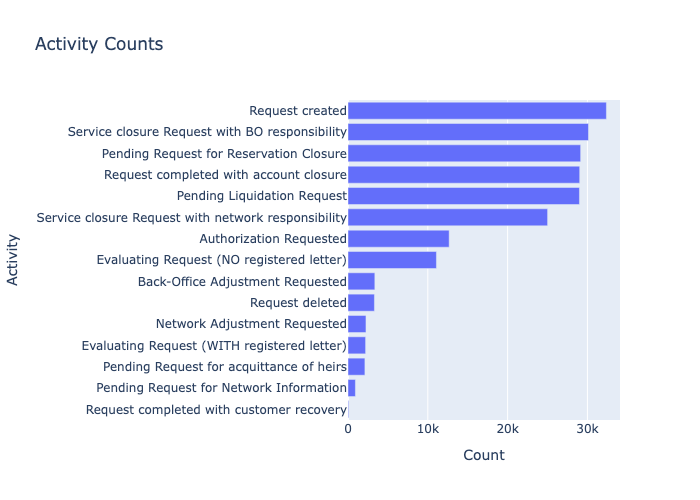
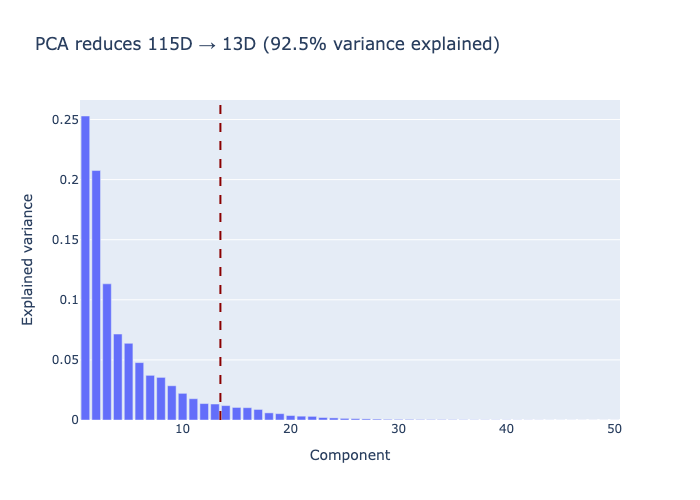
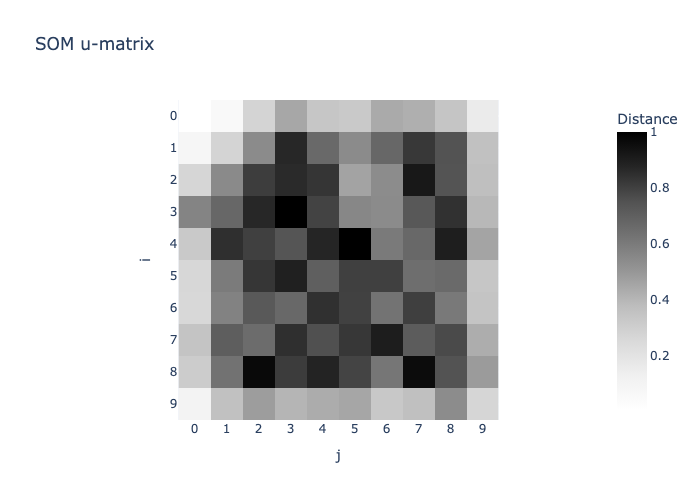
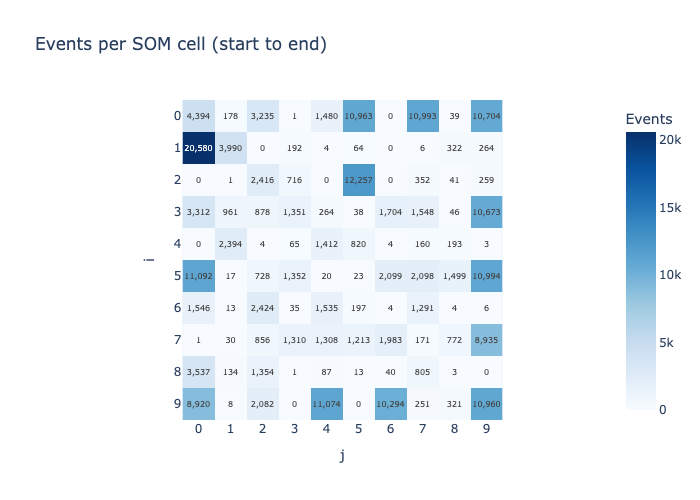
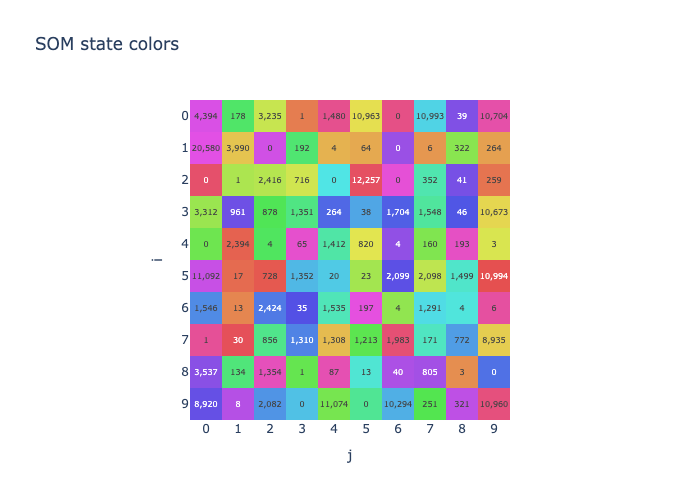
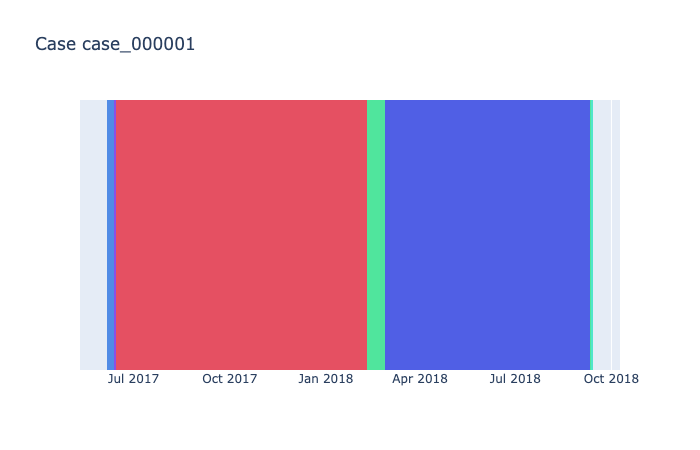
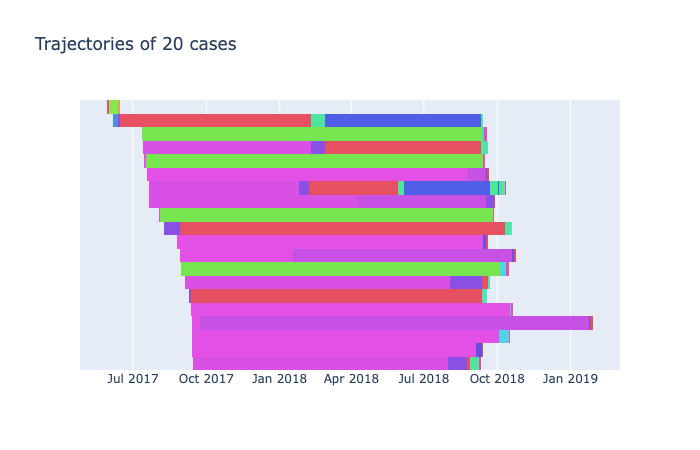
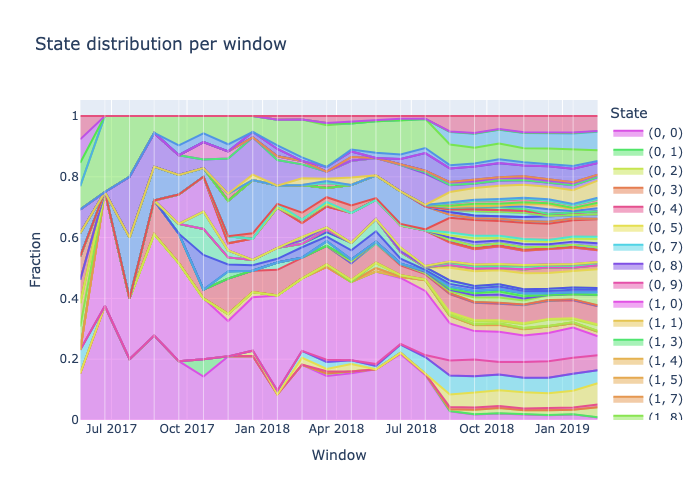
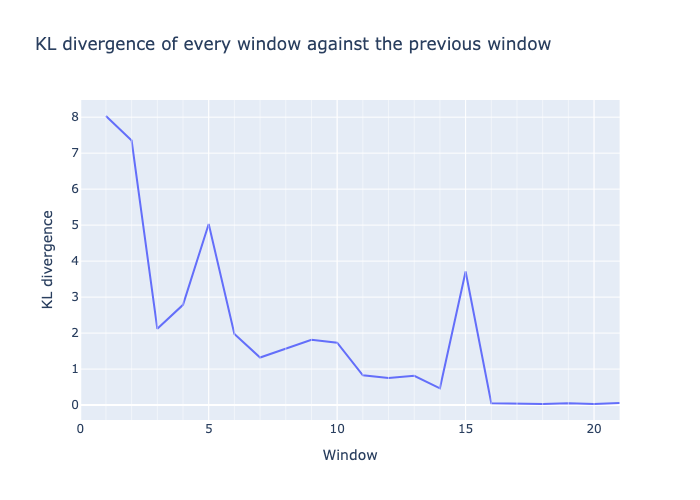

In [46]:
inp_tokens = kairo.count_input_tokens(provider="custom",
                                system_prompt=kairo.DEFAULT_SYSTEM_PROMPT, 
                                prompts=[abs_log_stats + abs_features + 
                                    abs_pca + abs_states + abs_case_trajectory + 
                                    abs_divergences + 
                                    "Very briefly analyze and summarize the given information. Do not use markdown format, just raw text"],
                                plots=[activity_plot, pca_plot_cut, u_matrix_plot, heatmap_plot,
                                           state_colors_plot, case_trajectory_plot, case_trajectories_plot,
                                            distributions_plot, divergences_plot])

inp_tokens

In [ ]:
out_to

In [114]:
llm = kairo.LLMConnector(
    provider="custom",
    #api_key=os.environ["ANTHROPIC_API_KEY"],
    model="Qwen/Qwen3-VL-32B-Instruct",
    base_url="http://137.226.117.70:8000/v1"
)

response = llm.call(
    prompt= abs_log_stats + abs_features + abs_pca + abs_states + abs_case_trajectory + 
    abs_divergences + "Very briefly analyze and summarize the given information. Do not use markdown format, just raw text",
    system_prompt=kairo.DEFAULT_SYSTEM_PROMPT,
    plots=[activity_plot, pca_plot_cut, u_matrix_plot, heatmap_plot,
           state_colors_plot, case_trajectory_plot, case_trajectories_plot,
           distributions_plot, divergences_plot],
)


In [115]:
answer = kairo.get_response_text(response)
print(answer)

The event log contains 212,721 events from 32,429 cases over 1 year 10 months, with 15 activities and 654 resources. Cases vary widely in length (2 to 23 events) and throughput time (0 to 503 days), with a median of 6 days and mean of 13.5 days. The most frequent activities are Request created and Service closure requests, while BOF is the most active resource.

Features were computed for each event, describing its case's prefix, resulting in a 212,721 × 115 matrix. PCA reduced this to 13 components explaining 92.5% of variance. The top components relate to activity sets, direct-follows patterns, and current/past activities, with pc_1 capturing states involving Pending Request for Reservation Closure and Service closure with BO responsibility.

A SOM with 5x5 grid identified 89 states. The most frequent states are (0,0) with 13.6% of events, followed by (3,9), (9,0), (0,4), and (3,7), all above 5%. Many states are sparse, with 30 states having fewer than 1% of events. State distances s